In [28]:
from dotenv import load_dotenv

load_dotenv()

True

In [29]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_anthropic import ChatAnthropic
from langsmith import Client

embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
    embedding_function = embedding,
    collection_name = 'real_estate_tax',
    persist_directory = './real_estate_tax_collection'
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 4,
        'fetch_k': 10,
        'lambda_mult': 0.6
    }
)

client = Client()

# 비용의 80%는 Haiku가, 정확도의 80%는 Sonnet/Opus가!!

smart_llm = ChatAnthropic(
    model='claude-opus-4-5-20251101',
    temperature= 0.1
)

llm = ChatAnthropic(
    model='claude-sonnet-4-5-20250929',
    temperature= 0.1
)

small_llm = ChatAnthropic(
    model='claude-haiku-4-5-20251001',
    temperature= 0.1
)

In [30]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: list 
    answer: str

In [31]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal


class Route(BaseModel):         # JSON 스키마보단 간단하고, TypedDict 상속보단 명확히 지시할 수 있는 Pandatic BaseModel 상속
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to December 2025.
'real_estate_tax' contains information about real estate tax up to December 2025.
if you think the question is not related either 'income_tax' or 'real_estate_tax'; use 'llm'
"""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

structured_router_llm = small_llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['income_tax', 'llm', 'real_estate_tax']:
    """
    사용자의 질문에 기반하여 적절한 경로를 결정합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        Literal['income_tax', 'llm', 'real_estate_tax']: 질문을 처리하기 위한 적절한 경로를 나타내는 문자열.
    """
    # state에서 질문을 추출합니다
    query = state['query']
    
    # 프롬프트와 구조화된 라우터 LLM을 연결하여 체인을 생성합니다
    router_chain = router_prompt | structured_router_llm 
    
    # 체인을 사용하여 경로를 결정합니다
    route = router_chain.invoke({'query': query})

    # 결정된 경로의 타겟을 반환합니다
    return route.target

In [32]:
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

def call_llm(state: AgentState):
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {'answer': llm_answer}

## build 시작

In [33]:
from TaxSelfRag import self_rag_graph
from RealEstateTaxCalculation import graph as real_estate_tax_calculation
from langgraph.graph import START, END

graph_builder.add_node('income_tax', self_rag_graph)
graph_builder.add_node('llm', call_llm)
graph_builder.add_node('real_estate_tax', real_estate_tax_calculation)

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'llm': 'llm',
        'real_estate_tax': 'real_estate_tax'

    }
)

graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('llm', END)
graph_builder.add_edge('real_estate_tax', END)

graph = graph_builder.compile()

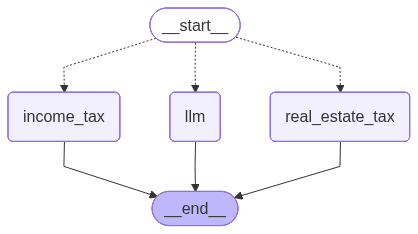

In [34]:
from IPython.display import display, Image

display(Image(graph.get_graph(xray=False).draw_mermaid_png()))

In [19]:
initial_state = {'query': '소득세란 무엇입니까?'}
answer = graph.invoke(initial_state)

In [21]:
answer['answer']

'소득세는 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세하는 세금입니다. 이는 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 합니다. 거주자와 비거주자 등 개인은 소득세법에 따라 각자의 소득에 대한 소득세를 납부할 의무를 집니다.'

In [22]:
initial_state = {'query': '10억짜리 집이 하나 있는 경우 종합부동산세를 알려주세요'}
answer = graph.invoke(initial_state)

In [26]:
answer['answer']

'# 종합부동산세 세액 계산\n\n## 1. 납세의무자 유형 확인\n- **1세대 1주택자** (주택 1채 보유)\n- 공시가격: 10억원\n\n## 2. 과세표준 확인\n- 과세표준: **0원**\n- (10억원 - 12억원 공제) × 45% = 음수 → 0원\n\n## 3. 적용 세율표\n과세표준이 0원이므로 세율 적용 불가\n\n## 4. 세액 계산\n```\n과세표준: 0원\n적용 세율: 해당 없음\n산출세액: 0원\n```\n\n## 최종 종합부동산세 산출세액\n\n**0원**\n\n---\n\n**결론**: 공시가격 10억원은 1세대 1주택자 공제금액(12억원)보다 적어 과세표준이 발생하지 않으므로, 종합부동산세는 **0원**입니다.'

In [35]:
initial_state = {'query': '회기역에서 저녁 먹을건데 맛집 추천좀 해줘'}
answer = graph.invoke(initial_state)

In [36]:
answer['answer']

'# 회기역 주변 맛집 추천\n\n회기역 근처에는 여러 맛집들이 있습니다. 몇 가지 추천해드릴게요:\n\n## 한식\n- **국밥/국수류** - 역 주변에 오래된 국밥집들이 많음\n- **고기구이** - 회기역 상권에 소규모 고깃집들 다수\n\n## 중식\n- 짜장면, 탕수육 등 중국식당들이 많은 편\n\n## 기타\n- **분식** - 떡볶이, 김밥 등 간편한 식사\n- **카페/디저트** - 저녁 후 카페 방문도 좋음\n\n---\n\n## 더 정확한 추천을 위해 알려주세요:\n- 🍖 선호하는 음식 종류?\n- 💰 예산대는?\n- 👥 몇 명이서 가시나요?\n- ⏰ 구체적인 시간대?\n\n이런 정보가 있으면 더 구체적으로 추천해드릴 수 있습니다!'